# Real Nuts ML Classifier: Wavelet + CNN Patch-Based Defect Detection

This notebook implements a defect detection classifier for factory-line hazelnut images using:
- **Wavelet transform** preprocessing (comparing single-channel cA vs multi-scale)
- **64x64 patch-based CNN** classifier
- **Leave-one-out cross-validation** to prevent data leakage

Based on the approach from `cnn_wavelet_hazelnut_1.ipynb` adapted for the `real_nuts_ml` dataset.

## 0. Setup and Configuration

In [1]:
from pathlib import Path
import random
import ast

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm

from sklearn.metrics import (
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
)

try:
    import pywt
except ImportError as exc:
    raise ImportError("PyWavelets required. Install with `pip install PyWavelets`.") from exc

try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
except ImportError as exc:
    raise ImportError("PyTorch required. Install with `pip install torch torchvision`.") from exc

# Reproducibility
SEED = 7
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Paths
DATA_DIR = Path("data/real_nuts_ml")
REAL_NUTS_DIR = Path("data/real_nuts")

# Image and patch configuration
IMG_SIZE = 256
PATCH_SIZE = 64
WAVELET = "db2"
WAVELET_LEVEL = 2

# Training configuration
BATCH_SIZE = 64
EPOCHS = 30
PATIENCE = 5
LR = 1e-3

# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# Plotting
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# Validate paths
if not DATA_DIR.exists():
    raise FileNotFoundError(f"Data directory not found: {DATA_DIR}")

Using device: cpu


## 1. Data Loading and Exploration

In [2]:
# Load manifests
defect_manifest = pd.read_csv(DATA_DIR / "defect_crops_manifest.csv")
nut_manifest = pd.read_csv(DATA_DIR / "nut_crops_manifest.csv")

print("Defect crops manifest:")
print(f"  Total crops: {len(defect_manifest)}")
print(f"  Source images: {defect_manifest['source_path'].nunique()}")
print(f"  Columns: {list(defect_manifest.columns)}")
print()

print("Nut crops manifest:")
print(f"  Total nuts: {len(nut_manifest)}")
print(f"  Defect: {(nut_manifest['label'] == 'defect').sum()}")
print(f"  Good: {(nut_manifest['label'] == 'good').sum()}")

defect_manifest.head(3)

Defect crops manifest:
  Total crops: 104
  Source images: 2
  Columns: ['source_path', 'real_path', 'crop_path', 'mask_path', 'full_mask_path', 'crop_source', 'cx', 'cy', 'radius', 'crop_size', 'out_size']

Nut crops manifest:
  Total nuts: 23
  Defect: 19
  Good: 4


,source_path,real_path,crop_path,mask_path,full_mask_path,crop_source,cx,cy,radius,crop_size,out_size
0,data/bad_nuts/IMG_1280.JPG,data/real_nuts/IMG_1280.JPG,data/real_nuts_ml/defect_crops_clean/IMG_1280_...,data/real_nuts_ml/defect_masks/IMG_1280_defect...,data/real_nuts_ml/defect_full_masks/IMG_1280_m...,clean,3072.265625,273.437500,89.843750,287,256
1,data/bad_nuts/IMG_1280.JPG,data/real_nuts/IMG_1280.JPG,data/real_nuts_ml/defect_crops_clean/IMG_1280_...,data/real_nuts_ml/defect_masks/IMG_1280_defect...,data/real_nuts_ml/defect_full_masks/IMG_1280_m...,clean,3349.609375,404.296875,201.171875,643,256
2,data/bad_nuts/IMG_1280.JPG,data/real_nuts/IMG_1280.JPG,data/real_nuts_ml/defect_crops_clean/IMG_1280_...,data/real_nuts_ml/defect_masks/IMG_1280_defect...,data/real_nuts_ml/defect_full_masks/IMG_1280_m...,clean,3242.187500,548.828125,91.796875,293,256


Defect crops per source image:
  IMG_1281.JPG: 82 crops
  IMG_1280.JPG: 22 crops


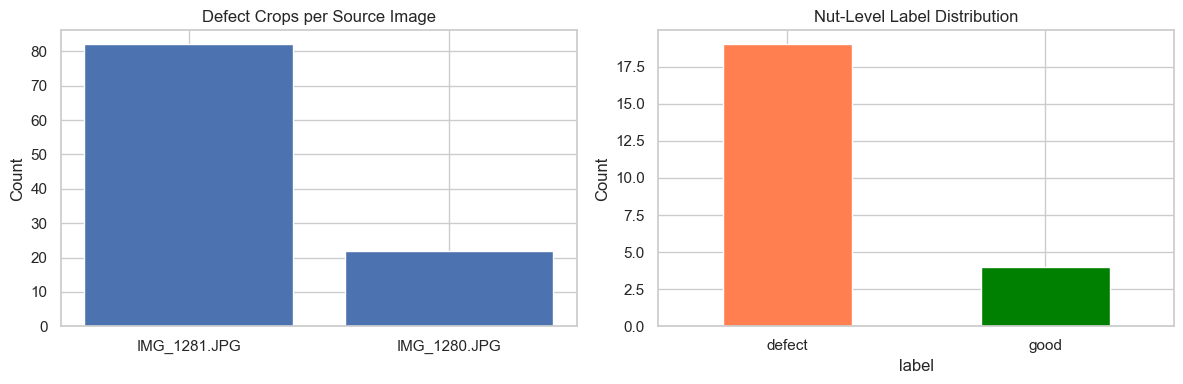

In [3]:
# Distribution of defect crops by source image
source_counts = defect_manifest['source_path'].value_counts()
print("Defect crops per source image:")
for src, count in source_counts.items():
    print(f"  {Path(src).name}: {count} crops")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar([Path(s).name for s in source_counts.index], source_counts.values)
axes[0].set_title("Defect Crops per Source Image")
axes[0].set_ylabel("Count")

nut_manifest['label'].value_counts().plot(kind='bar', ax=axes[1], color=['coral', 'green'])
axes[1].set_title("Nut-Level Label Distribution")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

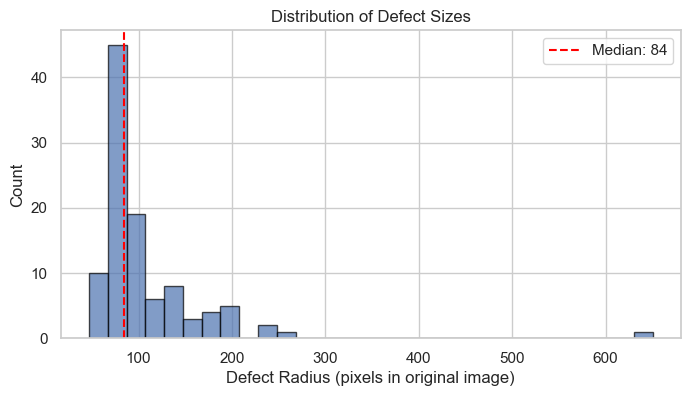

Radius range: 46.9 - 650.4 pixels


In [4]:
# Defect size distribution (radius)
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(defect_manifest['radius'], bins=30, edgecolor='black', alpha=0.7)
ax.set_xlabel("Defect Radius (pixels in original image)")
ax.set_ylabel("Count")
ax.set_title("Distribution of Defect Sizes")
ax.axvline(defect_manifest['radius'].median(), color='red', linestyle='--', label=f"Median: {defect_manifest['radius'].median():.0f}")
ax.legend()
plt.show()

print(f"Radius range: {defect_manifest['radius'].min():.1f} - {defect_manifest['radius'].max():.1f} pixels")

In [5]:
# Helper functions for loading images
def load_gray(path, size=IMG_SIZE):
    """Load image as grayscale, resize, and normalize to [0, 1]."""
    img = Image.open(path).convert("L")
    if size:
        img = img.resize((size, size), Image.BILINEAR)
    return np.asarray(img, dtype=np.float32) / 255.0


def load_mask(path, size=IMG_SIZE):
    """Load binary mask."""
    mask = Image.open(path).convert("L")
    if size:
        mask = mask.resize((size, size), Image.NEAREST)
    return (np.asarray(mask, dtype=np.float32) > 127).astype(np.float32)


def overlay_mask(img, mask, alpha=0.4):
    """Overlay mask on grayscale image in red."""
    rgb = np.dstack([img, img, img])
    red_overlay = rgb.copy()
    red_overlay[..., 0] = 1.0
    red_overlay[..., 1] = 0.0
    red_overlay[..., 2] = 0.0
    mask_3d = mask[..., None]
    return np.where(mask_3d > 0.5, (1 - alpha) * rgb + alpha * red_overlay, rgb)

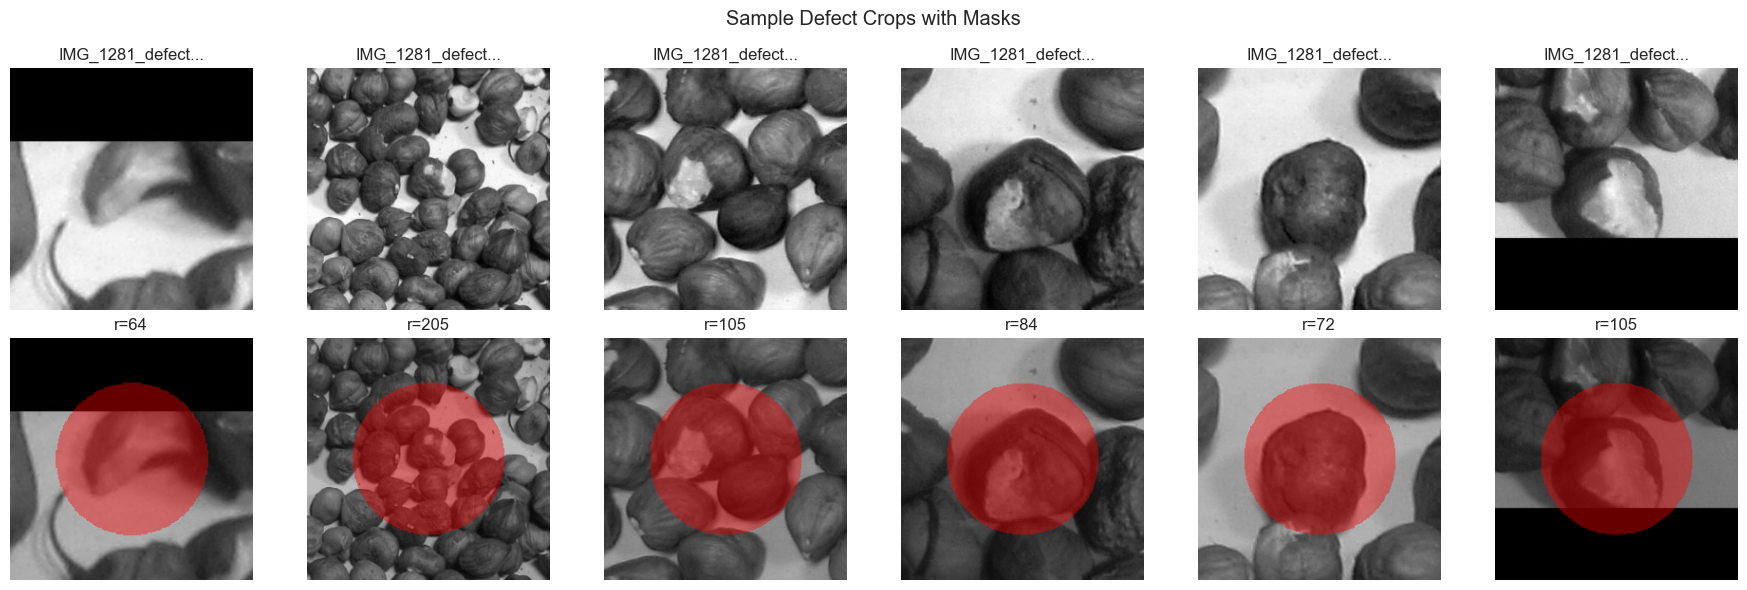

In [6]:
# Visualize sample defect crops with masks
n_samples = 6
sample_rows = defect_manifest.sample(n=n_samples, random_state=SEED)

fig, axes = plt.subplots(2, n_samples, figsize=(3 * n_samples, 6))

for i, (_, row) in enumerate(sample_rows.iterrows()):
    crop_path = Path(row['crop_path'])
    mask_path = Path(row['mask_path'])
    
    img = load_gray(crop_path)
    mask = load_mask(mask_path)
    
    axes[0, i].imshow(img, cmap='gray')
    axes[0, i].set_title(f"{crop_path.stem[:15]}...")
    axes[0, i].axis('off')
    
    axes[1, i].imshow(overlay_mask(img, mask))
    axes[1, i].set_title(f"r={row['radius']:.0f}")
    axes[1, i].axis('off')

axes[0, 0].set_ylabel("Crop", fontsize=12)
axes[1, 0].set_ylabel("With Mask", fontsize=12)
plt.suptitle("Sample Defect Crops with Masks")
plt.tight_layout()
plt.show()

## 2. Multi-Scale Wavelet Preprocessing

We implement two wavelet modes for comparison:
- **cA-only**: Single-channel approximation (baseline, matches existing approach)
- **multi-scale**: 7 channels - approximation + all detail bands from 2 levels

In [7]:
def wavelet_transform(img, mode='multi-scale', wavelet=WAVELET, level=WAVELET_LEVEL):
    """
    Apply wavelet transform to an image.
    
    Args:
        img: 2D numpy array (H, W) normalized to [0, 1]
        mode: 'cA-only' for single channel or 'multi-scale' for all bands
        wavelet: wavelet family (default: 'db2')
        level: decomposition level (default: 2)
    
    Returns:
        (C, H, W) numpy array where C depends on mode
    """
    coeffs = pywt.wavedec2(img, wavelet=wavelet, level=level)
    
    if mode == 'cA-only':
        # Just the approximation at deepest level
        cA = coeffs[0]
        return cA[np.newaxis, ...]
    
    elif mode == 'multi-scale':
        # Collect all coefficients: cA + all (cH, cV, cD) at each level
        channels = [coeffs[0]]  # Approximation at deepest level
        
        for level_coeffs in coeffs[1:]:
            cH, cV, cD = level_coeffs
            channels.extend([cH, cV, cD])
        
        # Resize all to match smallest size (deepest level)
        target_shape = coeffs[0].shape
        resized = []
        for ch in channels:
            if ch.shape != target_shape:
                ch_img = Image.fromarray(ch.astype(np.float32))
                ch_img = ch_img.resize(target_shape[::-1], Image.BILINEAR)
                ch = np.array(ch_img)
            resized.append(ch)
        
        return np.stack(resized, axis=0)
    
    else:
        raise ValueError(f"Unknown mode: {mode}")


def normalize_for_display(arr):
    """Normalize array to [0, 1] for display."""
    arr = arr - arr.min()
    if arr.max() > 0:
        arr = arr / arr.max()
    return arr

In [8]:
# Demonstrate wavelet transform on a sample image
sample_crop = defect_manifest.iloc[0]['crop_path']
sample_img = load_gray(sample_crop)

# Apply both modes
wavelet_cA = wavelet_transform(sample_img, mode='cA-only')
wavelet_multi = wavelet_transform(sample_img, mode='multi-scale')

print(f"Original image shape: {sample_img.shape}")
print(f"cA-only output shape: {wavelet_cA.shape}")
print(f"Multi-scale output shape: {wavelet_multi.shape}")

Original image shape: (256, 256)
cA-only output shape: (1, 66, 66)
Multi-scale output shape: (7, 66, 66)


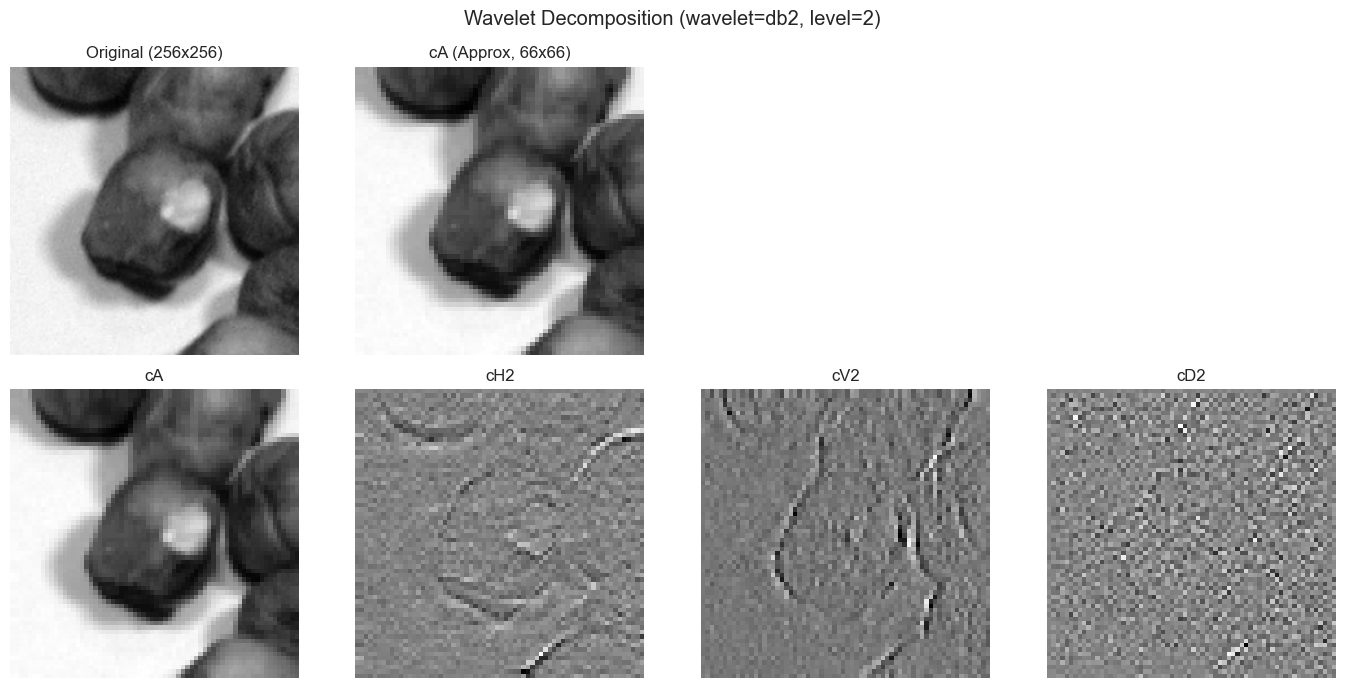

In [9]:
# Visualize wavelet channels
fig, axes = plt.subplots(2, 4, figsize=(14, 7))

# Top row: Original and cA-only
axes[0, 0].imshow(sample_img, cmap='gray')
axes[0, 0].set_title(f"Original ({sample_img.shape[0]}x{sample_img.shape[1]})")
axes[0, 0].axis('off')

axes[0, 1].imshow(normalize_for_display(wavelet_cA[0]), cmap='gray')
axes[0, 1].set_title(f"cA (Approx, {wavelet_cA.shape[1]}x{wavelet_cA.shape[2]})")
axes[0, 1].axis('off')

axes[0, 2].axis('off')
axes[0, 3].axis('off')

# Bottom row: Multi-scale channels
channel_names = ['cA', 'cH2', 'cV2', 'cD2']
for i in range(4):
    axes[1, i].imshow(normalize_for_display(wavelet_multi[i]), cmap='gray')
    axes[1, i].set_title(f"{channel_names[i]}")
    axes[1, i].axis('off')

plt.suptitle(f"Wavelet Decomposition (wavelet={WAVELET}, level={WAVELET_LEVEL})")
plt.tight_layout()
plt.show()

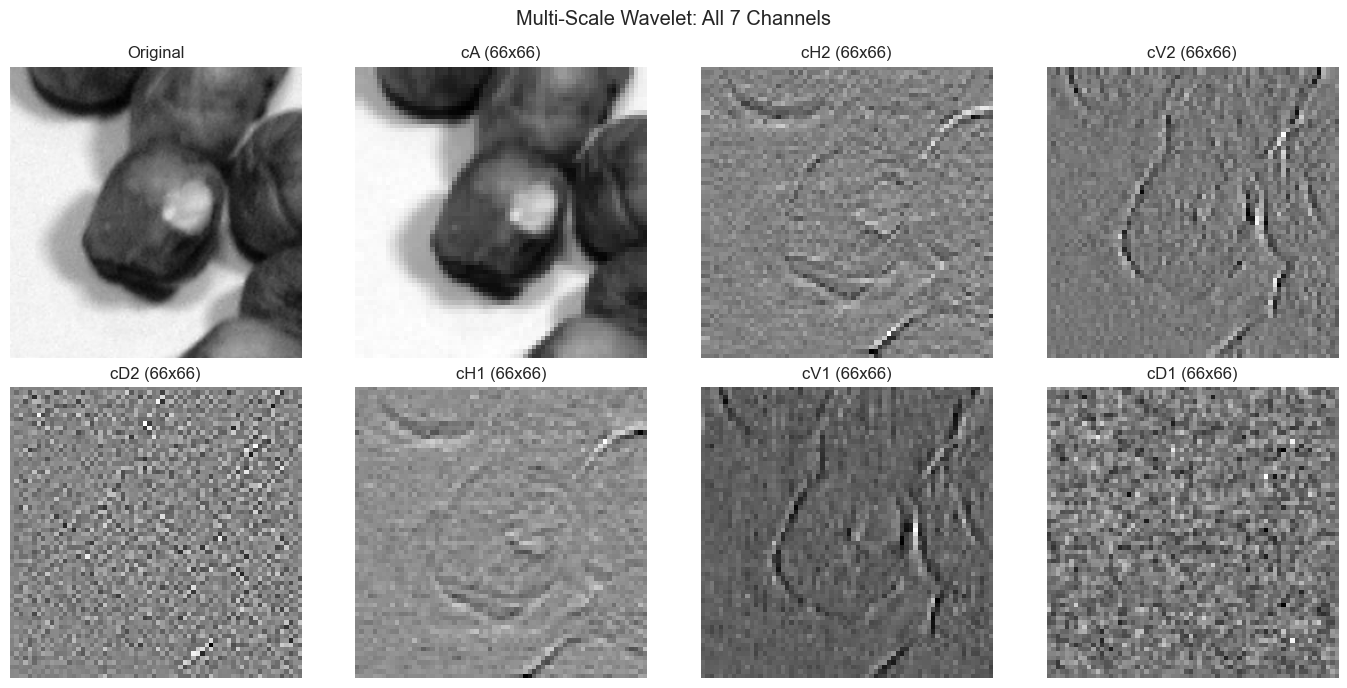

In [10]:
# Show all 7 channels of multi-scale
channel_names_full = ['cA', 'cH2', 'cV2', 'cD2', 'cH1', 'cV1', 'cD1']

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.ravel()

axes[0].imshow(sample_img, cmap='gray')
axes[0].set_title("Original")
axes[0].axis('off')

for i, name in enumerate(channel_names_full):
    axes[i + 1].imshow(normalize_for_display(wavelet_multi[i]), cmap='gray')
    axes[i + 1].set_title(f"{name} ({wavelet_multi[i].shape[0]}x{wavelet_multi[i].shape[1]})")
    axes[i + 1].axis('off')

plt.suptitle("Multi-Scale Wavelet: All 7 Channels")
plt.tight_layout()
plt.show()

## 3. Patch Extraction Strategy

We extract 64x64 patches from wavelet-transformed images:
- **Defect patches**: Sampled around mask centroids with random offset
- **Good patches**: Sampled from mask-free regions of defect crops
- **Good patches from unlabeled**: Random patches from the 18 unlabeled real_nuts images

In [11]:
def extract_defect_patches(wavelet_img, mask, n_patches, patch_size=PATCH_SIZE, max_offset=8):
    """
    Extract patches centered around defect regions with random offset.
    
    Args:
        wavelet_img: (C, H, W) wavelet-transformed image
        mask: (H, W) binary mask (same resolution as wavelet_img spatial dims)
        n_patches: number of patches to extract
        patch_size: size of square patches
        max_offset: maximum random offset from mask centroid
    
    Returns:
        List of (C, patch_size, patch_size) patches
    """
    _, h, w = wavelet_img.shape
    ys, xs = np.where(mask > 0.5)
    
    if len(ys) == 0:
        return []
    
    patches = []
    for _ in range(n_patches):
        idx = random.randrange(len(ys))
        cy, cx = ys[idx], xs[idx]
        
        # Add random offset
        oy = random.randint(-max_offset, max_offset)
        ox = random.randint(-max_offset, max_offset)
        
        # Compute top-left corner
        y = min(max(cy - patch_size // 2 + oy, 0), h - patch_size)
        x = min(max(cx - patch_size // 2 + ox, 0), w - patch_size)
        
        patches.append(wavelet_img[:, y:y+patch_size, x:x+patch_size].copy())
    
    return patches


def extract_good_patches_from_crop(wavelet_img, mask, n_patches, patch_size=PATCH_SIZE, min_good_ratio=0.95):
    """
    Extract patches from regions with minimal mask overlap (good regions).
    
    Args:
        wavelet_img: (C, H, W) wavelet-transformed image
        mask: (H, W) binary mask
        n_patches: target number of patches
        patch_size: size of square patches
        min_good_ratio: minimum fraction of patch that must be mask-free
    
    Returns:
        List of (C, patch_size, patch_size) patches
    """
    _, h, w = wavelet_img.shape
    patches = []
    max_attempts = n_patches * 20
    
    for _ in range(max_attempts):
        if len(patches) >= n_patches:
            break
        
        y = random.randint(0, h - patch_size)
        x = random.randint(0, w - patch_size)
        
        mask_patch = mask[y:y+patch_size, x:x+patch_size]
        good_ratio = 1 - mask_patch.mean()
        
        if good_ratio >= min_good_ratio:
            patches.append(wavelet_img[:, y:y+patch_size, x:x+patch_size].copy())
    
    return patches


def extract_random_patches(wavelet_img, n_patches, patch_size=PATCH_SIZE):
    """
    Extract random patches from an image (for unlabeled images assumed to be good).
    
    Args:
        wavelet_img: (C, H, W) wavelet-transformed image
        n_patches: number of patches to extract
        patch_size: size of square patches
    
    Returns:
        List of (C, patch_size, patch_size) patches
    """
    _, h, w = wavelet_img.shape
    patches = []
    
    for _ in range(n_patches):
        y = random.randint(0, h - patch_size)
        x = random.randint(0, w - patch_size)
        patches.append(wavelet_img[:, y:y+patch_size, x:x+patch_size].copy())
    
    return patches

In [12]:
def build_patch_dataset(manifest_df, wavelet_mode='cA-only', patches_per_defect=8, patches_per_good=6):
    """
    Build patch dataset from defect crop manifest.
    
    Args:
        manifest_df: DataFrame with crop_path, mask_path columns
        wavelet_mode: 'cA-only' or 'multi-scale'
        patches_per_defect: patches to extract from defect regions per crop
        patches_per_good: patches to extract from good regions per crop
    
    Returns:
        X: (N, C, H, W) array of patches
        y: (N,) array of labels (0=good, 1=defect)
        sources: list of source image names for each patch
    """
    X_defect, X_good = [], []
    sources_defect, sources_good = [], []
    
    for _, row in tqdm(manifest_df.iterrows(), total=len(manifest_df), desc=f"Building patches ({wavelet_mode})"):
        crop_path = Path(row['crop_path'])
        mask_path = Path(row['mask_path'])
        source_name = Path(row['source_path']).stem
        
        # Load and transform
        img = load_gray(crop_path)
        wavelet_img = wavelet_transform(img, mode=wavelet_mode)
        
        # Load mask and resize to wavelet spatial dimensions
        mask_full = load_mask(mask_path)
        wavelet_h, wavelet_w = wavelet_img.shape[1:]
        mask_resized = np.array(Image.fromarray(mask_full).resize((wavelet_w, wavelet_h), Image.NEAREST))
        
        # Extract defect patches
        defect_patches = extract_defect_patches(wavelet_img, mask_resized, patches_per_defect)
        X_defect.extend(defect_patches)
        sources_defect.extend([source_name] * len(defect_patches))
        
        # Extract good patches from mask-free regions
        good_patches = extract_good_patches_from_crop(wavelet_img, mask_resized, patches_per_good)
        X_good.extend(good_patches)
        sources_good.extend([source_name] * len(good_patches))
    
    # Combine
    X = np.stack(X_defect + X_good).astype(np.float32)
    y = np.array([1] * len(X_defect) + [0] * len(X_good), dtype=np.int64)
    sources = sources_defect + sources_good
    
    print(f"Total patches: {len(X)} (defect: {len(X_defect)}, good: {len(X_good)})")
    
    return X, y, sources

In [13]:
def add_unlabeled_good_patches(X, y, sources, wavelet_mode='cA-only', patches_per_image=50):
    """
    Add good patches from unlabeled real_nuts images.
    
    Args:
        X, y, sources: existing patch dataset
        wavelet_mode: 'cA-only' or 'multi-scale'
        patches_per_image: patches to extract from each unlabeled image
    
    Returns:
        Updated X, y, sources
    """
    # Find unlabeled images (not in manifest)
    labeled_images = set(defect_manifest['source_path'].apply(lambda x: Path(x).stem).unique())
    
    unlabeled_paths = []
    for ext in ['*.jpg', '*.JPG', '*.png', '*.PNG']:
        unlabeled_paths.extend(REAL_NUTS_DIR.glob(ext))
    
    unlabeled_paths = [p for p in unlabeled_paths if p.stem not in labeled_images]
    print(f"Found {len(unlabeled_paths)} unlabeled images in {REAL_NUTS_DIR}")
    
    if len(unlabeled_paths) == 0:
        return X, y, sources
    
    new_patches = []
    new_sources = []
    
    for img_path in tqdm(unlabeled_paths, desc="Extracting from unlabeled"):
        # Load full image and resize to standard size
        img = Image.open(img_path).convert("L")
        img = img.resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR)
        img_arr = np.asarray(img, dtype=np.float32) / 255.0
        
        wavelet_img = wavelet_transform(img_arr, mode=wavelet_mode)
        patches = extract_random_patches(wavelet_img, patches_per_image)
        
        new_patches.extend(patches)
        new_sources.extend([f"unlabeled_{img_path.stem}"] * len(patches))
    
    if len(new_patches) > 0:
        new_X = np.stack(new_patches).astype(np.float32)
        new_y = np.zeros(len(new_patches), dtype=np.int64)  # All good
        
        X = np.concatenate([X, new_X], axis=0)
        y = np.concatenate([y, new_y], axis=0)
        sources = sources + new_sources
        
        print(f"Added {len(new_patches)} good patches from unlabeled images")
    
    return X, y, sources

## 4. Train/Val Split (Leave-One-Out)

We split by source image to prevent data leakage:
- **Fold 1**: Train on IMG_1280, validate on IMG_1281
- **Fold 2**: Train on IMG_1281, validate on IMG_1280

Unlabeled image patches go to train set (they're from different source images).

In [14]:
def create_leave_one_out_split(X, y, sources, val_source):
    """
    Create train/val split where val_source is held out for validation.
    
    Args:
        X: (N, C, H, W) patches
        y: (N,) labels
        sources: list of source names
        val_source: source name to use for validation (e.g., 'IMG_1281')
    
    Returns:
        X_train, y_train, X_val, y_val
    """
    sources = np.array(sources)
    
    val_mask = sources == val_source
    train_mask = ~val_mask
    
    X_train, y_train = X[train_mask], y[train_mask]
    X_val, y_val = X[val_mask], y[val_mask]
    
    print(f"Validation source: {val_source}")
    print(f"Train: {len(X_train)} patches (defect: {y_train.sum()}, good: {len(y_train) - y_train.sum()})")
    print(f"Val: {len(X_val)} patches (defect: {y_val.sum()}, good: {len(y_val) - y_val.sum()})")
    
    return X_train, y_train, X_val, y_val

## 5. Data Augmentation and Dataset Class

In [15]:
class WaveletPatchDataset(Dataset):
    """Dataset for wavelet patches with optional augmentation."""
    
    def __init__(self, patches, labels, augment=False):
        self.patches = patches
        self.labels = labels
        self.augment = augment
    
    def __len__(self):
        return len(self.patches)
    
    def __getitem__(self, idx):
        patch = self.patches[idx].copy()
        label = self.labels[idx]
        
        if self.augment:
            # Random rotation (90, 180, 270 degrees)
            if random.random() > 0.5:
                k = random.randint(1, 3)
                patch = np.rot90(patch, k, axes=(1, 2)).copy()
            
            # Random flip
            if random.random() > 0.5:
                axis = random.choice([1, 2])
                patch = np.flip(patch, axis=axis).copy()
            
            # Slight contrast adjustment
            if random.random() > 0.7:
                factor = random.uniform(0.9, 1.1)
                patch = np.clip(patch * factor, 0, 1)
        
        return torch.FloatTensor(patch), label


def create_weighted_sampler(labels):
    """Create WeightedRandomSampler for class balancing."""
    class_counts = np.bincount(labels)
    class_weights = 1.0 / class_counts
    sample_weights = class_weights[labels]
    return WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

## 6. Model Architecture

Enhanced PatchCNN with BatchNorm and Dropout.

In [16]:
class MultiChannelPatchCNN(nn.Module):
    """CNN for classifying wavelet patches."""
    
    def __init__(self, in_channels=1, num_classes=2):
        super().__init__()
        
        self.features = nn.Sequential(
            # Block 1: 64 -> 32
            nn.Conv2d(in_channels, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            # Block 2: 32 -> 16
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            # Block 3: 16 -> 8
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            # Block 4: 8 -> 4
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(256 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )
    
    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


class SEBlock(nn.Module):
    """Squeeze-and-Excitation block for channel attention."""
    
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.squeeze = nn.AdaptiveAvgPool2d(1)
        self.excitation = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.squeeze(x).view(b, c)
        y = self.excitation(y).view(b, c, 1, 1)
        return x * y.expand_as(x)


class SEPatchCNN(nn.Module):
    """PatchCNN with Squeeze-and-Excitation attention."""
    
    def __init__(self, in_channels=1, num_classes=2):
        super().__init__()
        
        self.block1 = nn.Sequential(
            nn.Conv2d(in_channels, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            SEBlock(32, reduction=8),
            nn.MaxPool2d(2),
        )
        
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            SEBlock(64, reduction=8),
            nn.MaxPool2d(2),
        )
        
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            SEBlock(128, reduction=16),
            nn.MaxPool2d(2),
        )
        
        self.block4 = nn.Sequential(
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            SEBlock(256, reduction=16),
            nn.MaxPool2d(2),
        )
        
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )
    
    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        return self.classifier(x)

In [17]:
# Test model architecture
test_input = torch.randn(2, 7, 64, 64)  # Multi-scale input
model = MultiChannelPatchCNN(in_channels=7)
output = model(test_input)
print(f"Model input: {test_input.shape}")
print(f"Model output: {output.shape}")
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Model input: torch.Size([2, 7, 64, 64])
Model output: torch.Size([2, 2])
Model parameters: 1,439,874


## 7. Training

With Focal Loss for class imbalance and early stopping.

In [18]:
class FocalLoss(nn.Module):
    """Focal Loss for handling class imbalance."""
    
    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
    
    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        return focal_loss.mean()


def train_model(model, train_loader, val_loader, epochs=EPOCHS, patience=PATIENCE, lr=LR):
    """
    Train model with early stopping.
    
    Returns:
        history: list of dicts with training metrics per epoch
    """
    model = model.to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)
    criterion = FocalLoss(alpha=0.25, gamma=2.0)
    
    best_val_auc = 0
    patience_counter = 0
    best_model_state = None
    history = []
    
    for epoch in range(1, epochs + 1):
        # Training
        model.train()
        train_loss, train_correct, train_total = 0, 0, 0
        
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * xb.size(0)
            train_correct += (logits.argmax(1) == yb).sum().item()
            train_total += xb.size(0)
        
        train_loss /= train_total
        train_acc = train_correct / train_total
        
        # Validation
        model.eval()
        val_probs, val_labels = [], []
        val_loss, val_correct, val_total = 0, 0, 0
        
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                logits = model(xb)
                loss = criterion(logits, yb)
                probs = F.softmax(logits, dim=1)[:, 1].cpu().numpy()
                
                val_loss += loss.item() * xb.size(0)
                val_correct += (logits.argmax(1) == yb).sum().item()
                val_total += xb.size(0)
                val_probs.extend(probs)
                val_labels.extend(yb.cpu().numpy())
        
        val_loss /= val_total
        val_acc = val_correct / val_total
        val_auc = roc_auc_score(val_labels, val_probs) if len(set(val_labels)) > 1 else 0
        
        scheduler.step(val_loss)
        
        history.append({
            'epoch': epoch,
            'train_loss': train_loss,
            'train_acc': train_acc,
            'val_loss': val_loss,
            'val_acc': val_acc,
            'val_auc': val_auc,
        })
        
        print(f"Epoch {epoch:02d} | "
              f"train loss {train_loss:.4f} acc {train_acc:.3f} | "
              f"val loss {val_loss:.4f} acc {val_acc:.3f} auc {val_auc:.3f}")
        
        # Early stopping
        if val_auc > best_val_auc:
            best_val_auc = val_auc
            patience_counter = 0
            best_model_state = model.state_dict().copy()
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch}")
                break
    
    # Restore best model
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
    
    return history

## 8. Evaluation Functions

In [19]:
def evaluate_model(model, val_loader, title="Validation"):
    """
    Evaluate model on validation set.
    
    Returns:
        dict with all_probs, all_labels, all_preds
    """
    model.eval()
    all_probs, all_labels, all_preds = [], [], []
    
    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(DEVICE)
            logits = model(xb)
            probs = F.softmax(logits, dim=1)[:, 1].cpu().numpy()
            preds = logits.argmax(1).cpu().numpy()
            
            all_probs.extend(probs)
            all_preds.extend(preds)
            all_labels.extend(yb.numpy())
    
    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)
    
    # Metrics
    print(f"\n{title} Results:")
    print("=" * 40)
    print("\nConfusion Matrix:")
    cm = confusion_matrix(all_labels, all_preds)
    print(cm)
    
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=['good', 'defect']))
    
    auc = roc_auc_score(all_labels, all_probs)
    print(f"ROC AUC: {auc:.4f}")
    
    return {'probs': all_probs, 'labels': all_labels, 'preds': all_preds, 'auc': auc}


def plot_training_history(history):
    """Plot training curves."""
    df = pd.DataFrame(history)
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    axes[0].plot(df['epoch'], df['train_loss'], label='train')
    axes[0].plot(df['epoch'], df['val_loss'], label='val')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Loss')
    axes[0].legend()
    
    axes[1].plot(df['epoch'], df['train_acc'], label='train')
    axes[1].plot(df['epoch'], df['val_acc'], label='val')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title('Accuracy')
    axes[1].legend()
    
    axes[2].plot(df['epoch'], df['val_auc'])
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('AUC')
    axes[2].set_title('Validation AUC')
    
    plt.tight_layout()
    plt.show()


def plot_roc_curve(results, title="ROC Curve"):
    """Plot ROC curve."""
    fpr, tpr, _ = roc_curve(results['labels'], results['probs'])
    
    plt.figure(figsize=(6, 6))
    plt.plot(fpr, tpr, label=f"AUC = {results['auc']:.3f}")
    plt.plot([0, 1], [0, 1], 'k--', label='Random')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

## 9. Run Experiments

Compare cA-only vs multi-scale wavelet modes with leave-one-out cross-validation.

In [20]:
# Build datasets for both wavelet modes
print("Building cA-only dataset...")
X_cA, y_cA, sources_cA = build_patch_dataset(defect_manifest, wavelet_mode='cA-only')
X_cA, y_cA, sources_cA = add_unlabeled_good_patches(X_cA, y_cA, sources_cA, wavelet_mode='cA-only', patches_per_image=30)

print("\nBuilding multi-scale dataset...")
X_multi, y_multi, sources_multi = build_patch_dataset(defect_manifest, wavelet_mode='multi-scale')
X_multi, y_multi, sources_multi = add_unlabeled_good_patches(X_multi, y_multi, sources_multi, wavelet_mode='multi-scale', patches_per_image=30)

Building cA-only dataset...


Building patches (cA-only): 100%|██████████| 104/104 [00:00<00:00, 272.47it/s]


Total patches: 832 (defect: 832, good: 0)
Found 18 unlabeled images in data/real_nuts


Extracting from unlabeled: 100%|██████████| 18/18 [00:02<00:00,  8.22it/s]


Added 540 good patches from unlabeled images

Building multi-scale dataset...


Building patches (multi-scale): 100%|██████████| 104/104 [00:00<00:00, 256.63it/s]


Total patches: 832 (defect: 832, good: 0)
Found 18 unlabeled images in data/real_nuts


Extracting from unlabeled: 100%|██████████| 18/18 [00:02<00:00,  8.45it/s]


Added 540 good patches from unlabeled images


In [21]:
# Determine source images for leave-one-out
labeled_sources = defect_manifest['source_path'].apply(lambda x: Path(x).stem).unique()
print(f"Labeled source images: {labeled_sources}")

Labeled source images: <StringArray>
['IMG_1280', 'IMG_1281']
Length: 2, dtype: str


In [22]:
def run_experiment(X, y, sources, wavelet_mode, val_source, model_class=MultiChannelPatchCNN):
    """
    Run a single experiment with specified configuration.
    """
    print(f"\n{'='*60}")
    print(f"Experiment: {wavelet_mode} | Val: {val_source}")
    print(f"{'='*60}")
    
    # Split data
    X_train, y_train, X_val, y_val = create_leave_one_out_split(X, y, sources, val_source)
    
    # Normalize using training statistics
    mean = X_train.mean()
    std = X_train.std() + 1e-6
    X_train_n = (X_train - mean) / std
    X_val_n = (X_val - mean) / std
    
    # Create datasets and loaders
    train_ds = WaveletPatchDataset(X_train_n, y_train, augment=True)
    val_ds = WaveletPatchDataset(X_val_n, y_val, augment=False)
    
    sampler = create_weighted_sampler(y_train)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE * 2, shuffle=False)
    
    # Create model
    in_channels = X.shape[1]
    model = model_class(in_channels=in_channels)
    
    # Train
    history = train_model(model, train_loader, val_loader)
    
    # Evaluate
    results = evaluate_model(model, val_loader, title=f"{wavelet_mode} | Val: {val_source}")
    
    # Plot
    plot_training_history(history)
    plot_roc_curve(results, title=f"ROC: {wavelet_mode} | Val: {val_source}")
    
    return {
        'wavelet_mode': wavelet_mode,
        'val_source': val_source,
        'val_auc': results['auc'],
        'val_acc': (results['preds'] == results['labels']).mean(),
        'model': model,
        'history': history,
        'mean': mean,
        'std': std,
    }

In [23]:
# Run experiments for cA-only mode
results_cA = []

for val_source in labeled_sources:
    result = run_experiment(X_cA, y_cA, sources_cA, 'cA-only', val_source)
    results_cA.append(result)


Experiment: cA-only | Val: IMG_1280
Validation source: IMG_1280
Train: 1196 patches (defect: 656, good: 540)
Val: 176 patches (defect: 176, good: 0)
Epoch 01 | train loss 0.0664 acc 0.846 | val loss 0.0000 acc 1.000 auc 0.000
Epoch 02 | train loss 0.0020 acc 0.989 | val loss 0.0001 acc 1.000 auc 0.000
Epoch 03 | train loss 0.0006 acc 0.996 | val loss 0.0000 acc 1.000 auc 0.000
Epoch 04 | train loss 0.0004 acc 0.999 | val loss 0.0000 acc 1.000 auc 0.000
Epoch 05 | train loss 0.0003 acc 0.999 | val loss 0.0000 acc 1.000 auc 0.000
Early stopping at epoch 5

cA-only | Val: IMG_1280 Results:

Confusion Matrix:
[[176]]

Classification Report:


/home/ianfeekes/Documents/sw_dev/hazelnuts/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


ValueError: Number of classes, 1, does not match size of target_names, 2. Try specifying the labels parameter


Experiment: multi-scale | Val: IMG_1280
Validation source: IMG_1280
Train: 1196 patches (defect: 656, good: 540)
Val: 176 patches (defect: 176, good: 0)
Epoch 01 | train loss 0.1147 acc 0.752 | val loss 0.0091 acc 1.000 auc 0.000
Epoch 02 | train loss 0.0171 acc 0.862 | val loss 0.0006 acc 1.000 auc 0.000
Epoch 03 | train loss 0.0138 acc 0.885 | val loss 0.0001 acc 1.000 auc 0.000
Epoch 04 | train loss 0.0132 acc 0.844 | val loss 0.0003 acc 1.000 auc 0.000
Epoch 05 | train loss 0.0138 acc 0.855 | val loss 0.0252 acc 0.955 auc 0.000
Early stopping at epoch 5

multi-scale | Val: IMG_1280 Results:

Confusion Matrix:
[[  0   0]
 [  8 168]]

Classification Report:
              precision    recall  f1-score   support

        good       0.00      0.00      0.00         0
      defect       1.00      0.95      0.98       176

    accuracy                           0.95       176
   macro avg       0.50      0.48      0.49       176
weighted avg       1.00      0.95      0.98       176

ROC 

/home/ianfeekes/Documents/sw_dev/hazelnuts/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/ianfeekes/Documents/sw_dev/hazelnuts/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/ianfeekes/Documents/sw_dev/hazelnuts/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

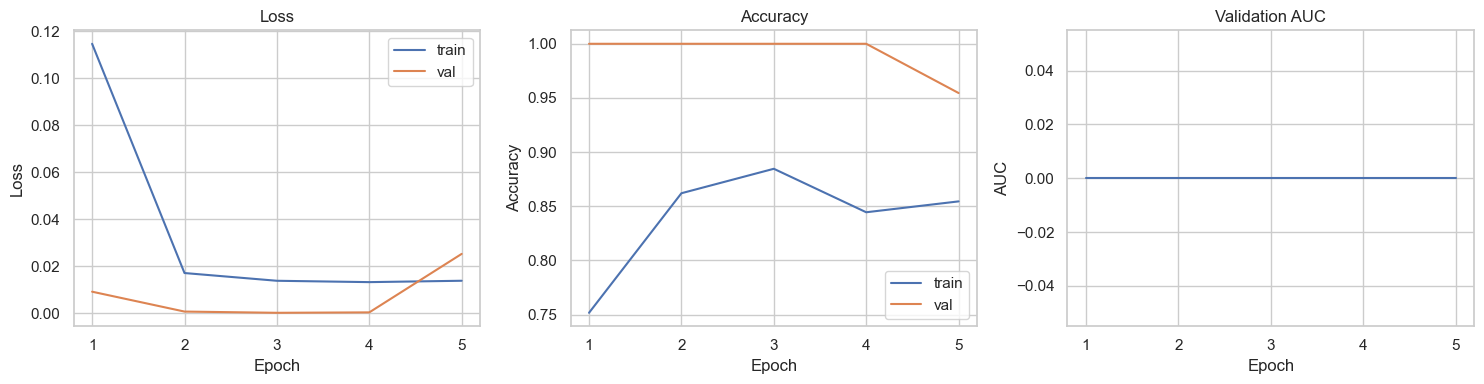

/home/ianfeekes/Documents/sw_dev/hazelnuts/.venv/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:1294: UndefinedMetricWarning: No negative samples in y_true, false positive value should be meaningless
  warnings.warn(


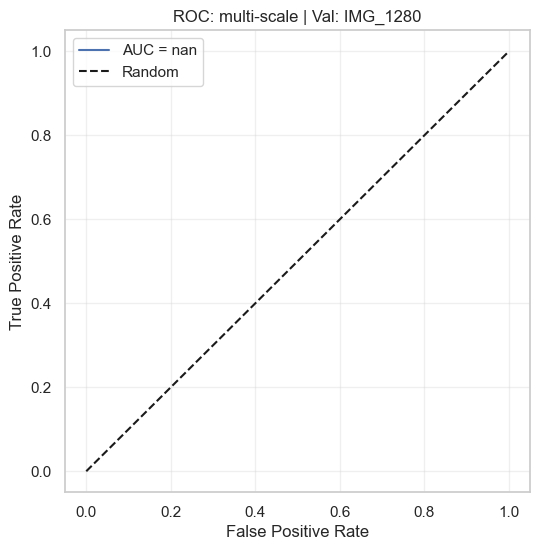


Experiment: multi-scale | Val: IMG_1281
Validation source: IMG_1281
Train: 716 patches (defect: 176, good: 540)
Val: 656 patches (defect: 656, good: 0)
Epoch 01 | train loss 0.0561 acc 0.799 | val loss 0.0198 acc 1.000 auc 0.000
Epoch 02 | train loss 0.0133 acc 0.884 | val loss 0.0000 acc 1.000 auc 0.000
Epoch 03 | train loss 0.0096 acc 0.969 | val loss 0.2614 acc 0.848 auc 0.000
Epoch 04 | train loss 0.0235 acc 0.849 | val loss 1.8904 acc 0.378 auc 0.000
Epoch 05 | train loss 0.0183 acc 0.835 | val loss 0.1957 acc 0.782 auc 0.000
Early stopping at epoch 5

multi-scale | Val: IMG_1281 Results:

Confusion Matrix:
[[  0   0]
 [143 513]]

Classification Report:
              precision    recall  f1-score   support

        good       0.00      0.00      0.00         0
      defect       1.00      0.78      0.88       656

    accuracy                           0.78       656
   macro avg       0.50      0.39      0.44       656
weighted avg       1.00      0.78      0.88       656

ROC A

/home/ianfeekes/Documents/sw_dev/hazelnuts/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/ianfeekes/Documents/sw_dev/hazelnuts/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/ianfeekes/Documents/sw_dev/hazelnuts/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

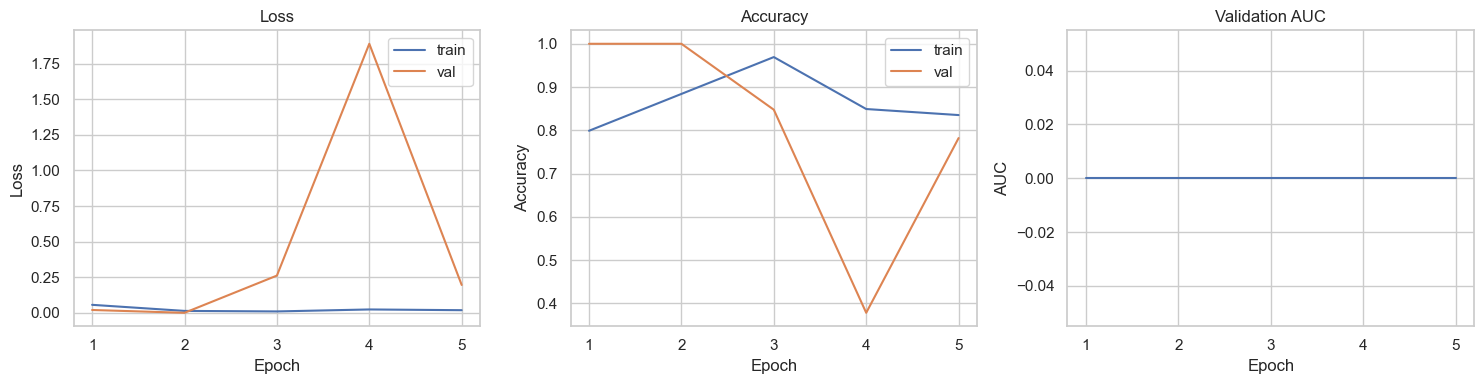

/home/ianfeekes/Documents/sw_dev/hazelnuts/.venv/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:1294: UndefinedMetricWarning: No negative samples in y_true, false positive value should be meaningless
  warnings.warn(


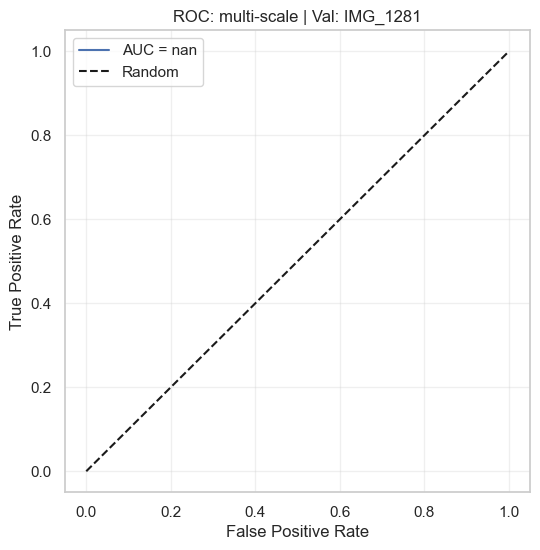

In [24]:
# Run experiments for multi-scale mode
results_multi = []

for val_source in labeled_sources:
    result = run_experiment(X_multi, y_multi, sources_multi, 'multi-scale', val_source)
    results_multi.append(result)

In [25]:
# Summary comparison
summary_rows = []

for r in results_cA + results_multi:
    summary_rows.append({
        'Wavelet Mode': r['wavelet_mode'],
        'Val Source': r['val_source'],
        'Val AUC': f"{r['val_auc']:.3f}",
        'Val Accuracy': f"{r['val_acc']:.3f}",
    })

summary_df = pd.DataFrame(summary_rows)
print("\n" + "="*60)
print("EXPERIMENT SUMMARY")
print("="*60)
print(summary_df.to_string(index=False))

# Average AUC per mode
print("\nAverage AUC by Wavelet Mode:")
avg_cA = np.mean([r['val_auc'] for r in results_cA])
avg_multi = np.mean([r['val_auc'] for r in results_multi])
print(f"  cA-only: {avg_cA:.3f}")
print(f"  multi-scale: {avg_multi:.3f}")


EXPERIMENT SUMMARY
Wavelet Mode Val Source Val AUC Val Accuracy
 multi-scale   IMG_1280     nan        0.955
 multi-scale   IMG_1281     nan        0.782

Average AUC by Wavelet Mode:
  cA-only: nan
  multi-scale: nan


/home/ianfeekes/Documents/sw_dev/hazelnuts/.venv/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/ianfeekes/Documents/sw_dev/hazelnuts/.venv/lib/python3.11/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


## 10. Image-Level Inference and Heatmaps

In [26]:
def sliding_window_inference(model, img_path, wavelet_mode, mean, std, stride=16, patch_size=PATCH_SIZE):
    """
    Run sliding window inference on an image.
    
    Returns:
        dict with patch probabilities, coordinates, and heatmap
    """
    model.eval()
    
    # Load and transform image
    img = load_gray(img_path)
    wavelet_img = wavelet_transform(img, mode=wavelet_mode)
    
    _, h, w = wavelet_img.shape
    
    # Extract patches with sliding window
    patches = []
    coords = []
    
    for y in range(0, h - patch_size + 1, stride):
        for x in range(0, w - patch_size + 1, stride):
            patch = wavelet_img[:, y:y+patch_size, x:x+patch_size]
            patches.append(patch)
            coords.append((y, x))
    
    # Normalize and predict
    patches = np.stack(patches)
    patches = (patches - mean) / std
    
    patches_t = torch.FloatTensor(patches).to(DEVICE)
    
    with torch.no_grad():
        probs = F.softmax(model(patches_t), dim=1)[:, 1].cpu().numpy()
    
    # Create heatmap
    heatmap = np.zeros((h, w))
    count_map = np.zeros((h, w))
    
    for (y, x), prob in zip(coords, probs):
        heatmap[y:y+patch_size, x:x+patch_size] += prob
        count_map[y:y+patch_size, x:x+patch_size] += 1
    
    heatmap = heatmap / np.maximum(count_map, 1)
    
    return {
        'probs': probs,
        'coords': coords,
        'heatmap': heatmap,
        'max_prob': probs.max(),
        'mean_prob': probs.mean(),
        'defect_count': (probs > 0.5).sum(),
    }


def visualize_heatmap(img_path, result, mask_path=None):
    """
    Visualize inference results with heatmap.
    """
    img = load_gray(img_path)
    heatmap = result['heatmap']
    
    # Resize heatmap to match image
    heatmap_resized = np.array(Image.fromarray(heatmap).resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR))
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    axes[0].imshow(img, cmap='gray')
    axes[0].set_title('Original')
    axes[0].axis('off')
    
    im = axes[1].imshow(heatmap_resized, cmap='hot', vmin=0, vmax=1)
    axes[1].set_title(f'Defect Probability (max={result["max_prob"]:.2f})')
    axes[1].axis('off')
    plt.colorbar(im, ax=axes[1], fraction=0.046)
    
    axes[2].imshow(img, cmap='gray')
    axes[2].imshow(heatmap_resized, cmap='hot', alpha=0.5, vmin=0, vmax=1)
    axes[2].set_title('Overlay')
    axes[2].axis('off')
    
    if mask_path:
        mask = load_mask(mask_path)
        for ax in axes:
            ax.contour(mask, colors='cyan', linewidths=1, levels=[0.5])
    
    plt.tight_layout()
    plt.show()

Using best model: multi-scale, Val AUC: nan

Processing: IMG_1281_defect_08.jpg


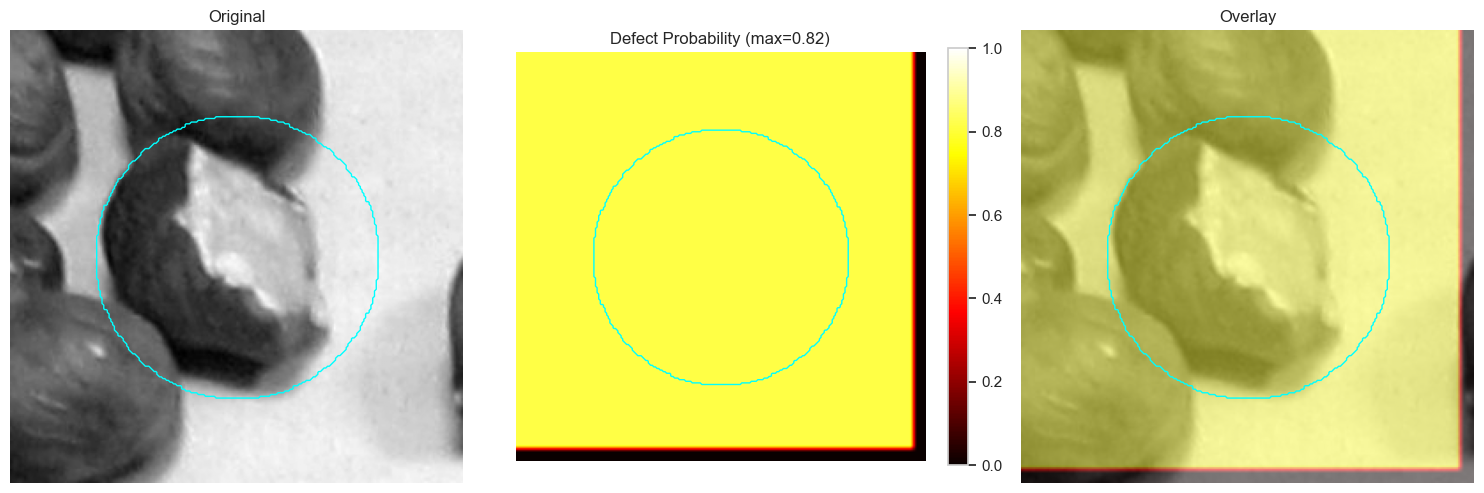


Processing: IMG_1281_defect_43.jpg


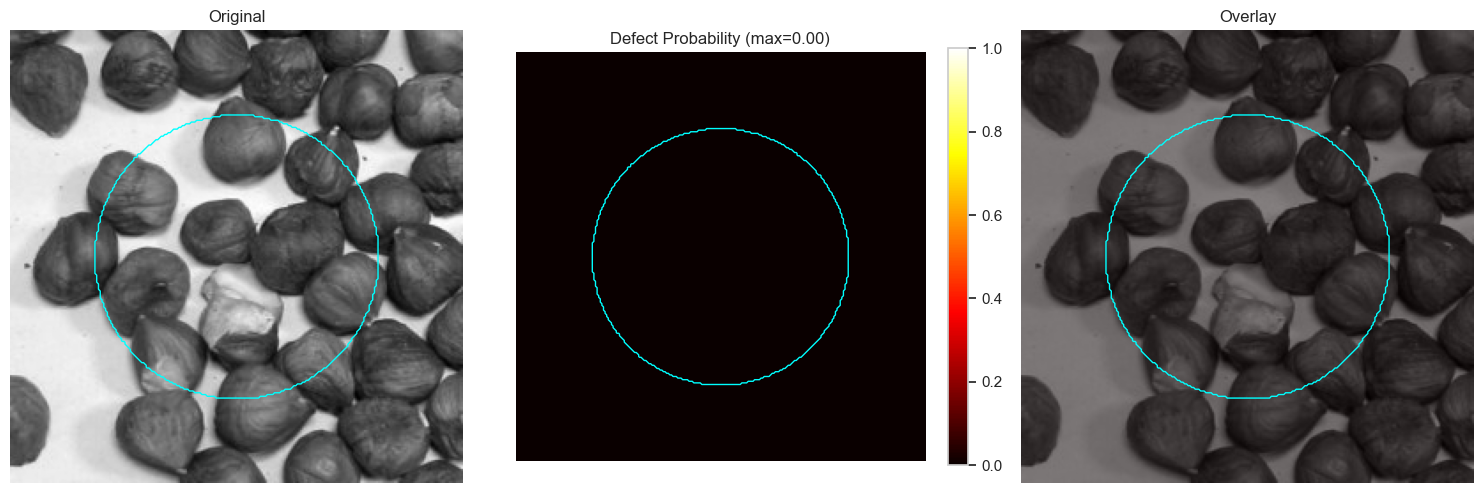


Processing: IMG_1281_defect_42.jpg


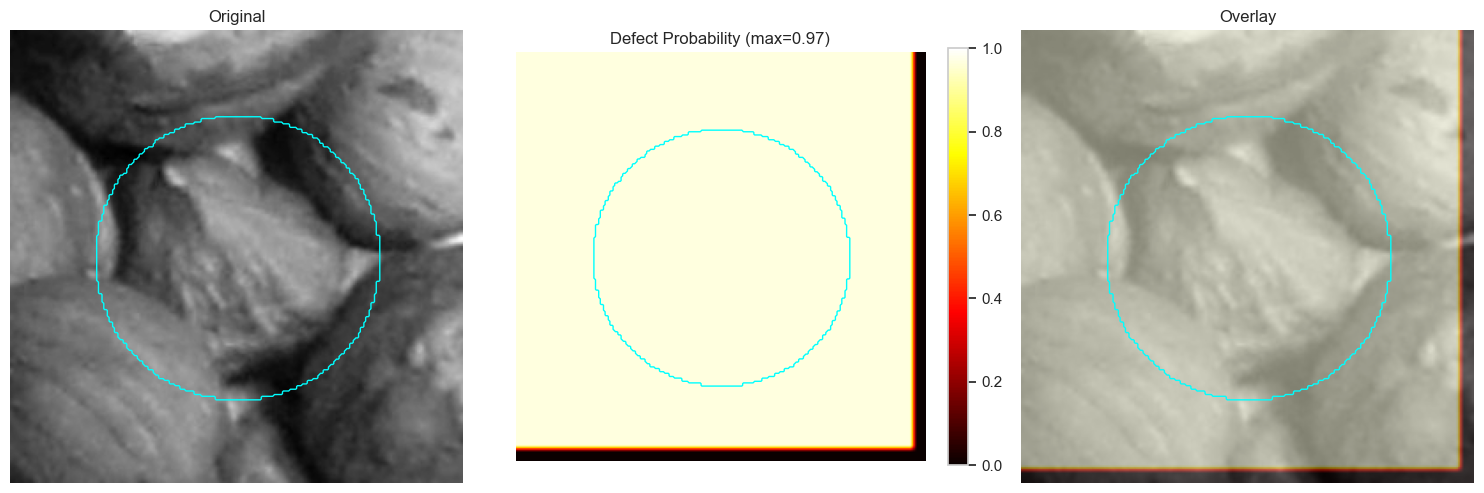


Processing: IMG_1281_defect_31.jpg


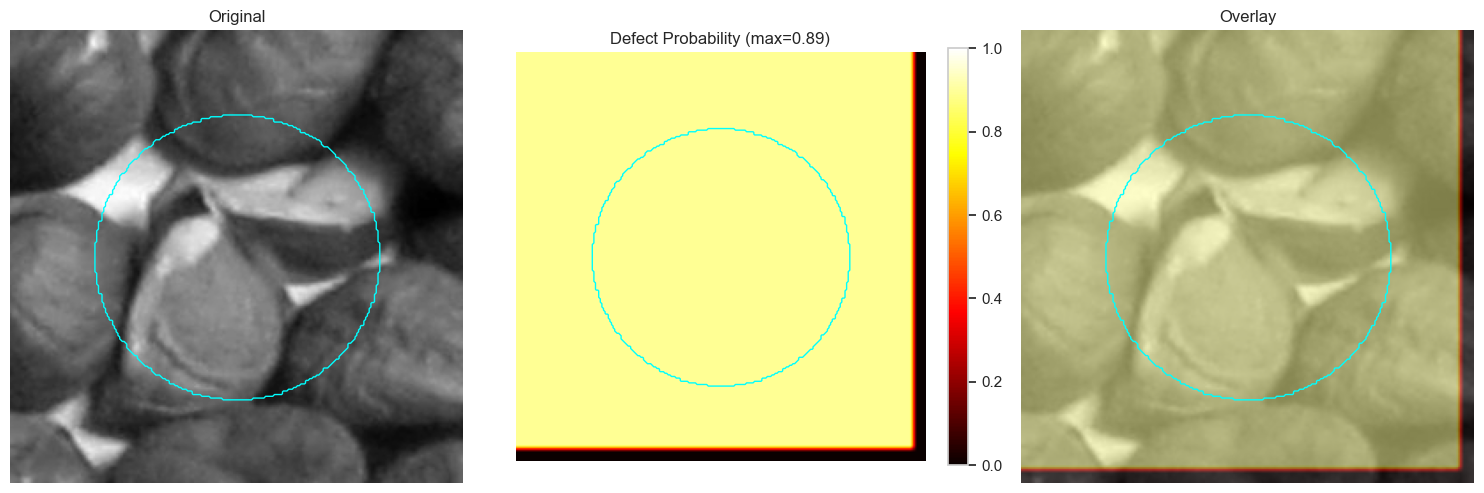

In [27]:
# Test heatmap visualization on a few samples
# Use the best performing model
best_result = max(results_multi, key=lambda x: x['val_auc'])
print(f"Using best model: {best_result['wavelet_mode']}, Val AUC: {best_result['val_auc']:.3f}")

sample_crops = defect_manifest.sample(n=4, random_state=42)

for _, row in sample_crops.iterrows():
    crop_path = Path(row['crop_path'])
    mask_path = Path(row['mask_path'])
    
    print(f"\nProcessing: {crop_path.name}")
    result = sliding_window_inference(
        best_result['model'],
        crop_path,
        best_result['wavelet_mode'],
        best_result['mean'],
        best_result['std']
    )
    
    visualize_heatmap(crop_path, result, mask_path)

## 11. Factory-Line Preprocessing Utilities

Additional preprocessing for real factory images with varying lighting.

In [28]:
from skimage import exposure
from skimage.filters import laplace


def apply_clahe(img, clip_limit=0.03):
    """
    Apply CLAHE (Contrast Limited Adaptive Histogram Equalization) to handle uneven lighting.
    
    Args:
        img: 2D numpy array normalized to [0, 1]
        clip_limit: clipping limit for CLAHE
    
    Returns:
        Enhanced image
    """
    return exposure.equalize_adapthist(img, clip_limit=clip_limit)


def compute_blur_score(img):
    """
    Compute Laplacian variance as a blur metric.
    Higher values = sharper image.
    """
    lap = laplace(img)
    return np.var(lap)


def preprocess_factory_image(img_path, apply_enhancement=True):
    """
    Preprocess a factory image for inference.
    
    Args:
        img_path: path to image
        apply_enhancement: whether to apply CLAHE
    
    Returns:
        Preprocessed image (H, W) normalized to [0, 1]
    """
    img = load_gray(img_path)
    
    blur_score = compute_blur_score(img)
    print(f"Blur score: {blur_score:.4f}")
    
    if apply_enhancement:
        img = apply_clahe(img)
    
    return img

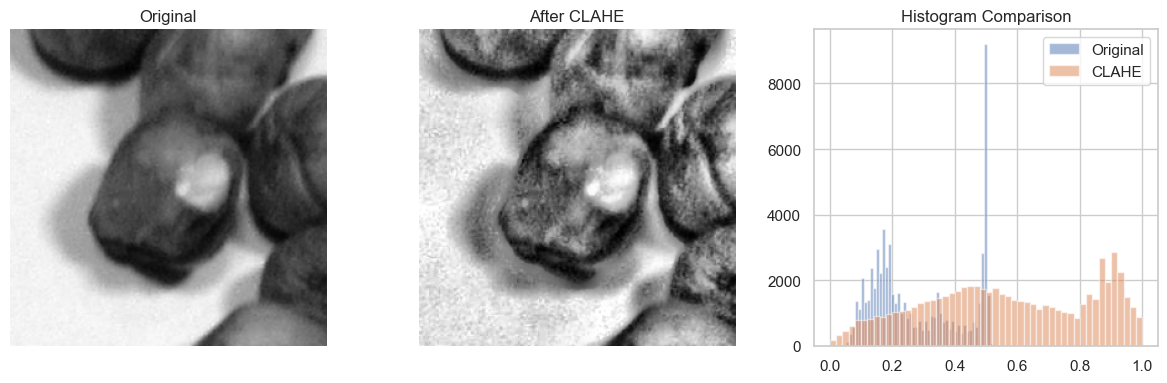

In [29]:
# Demonstrate preprocessing
sample_path = defect_manifest.iloc[0]['crop_path']

img_original = load_gray(sample_path)
img_clahe = apply_clahe(img_original)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(img_original, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(img_clahe, cmap='gray')
axes[1].set_title('After CLAHE')
axes[1].axis('off')

# Histogram comparison
axes[2].hist(img_original.ravel(), bins=50, alpha=0.5, label='Original')
axes[2].hist(img_clahe.ravel(), bins=50, alpha=0.5, label='CLAHE')
axes[2].set_title('Histogram Comparison')
axes[2].legend()

plt.tight_layout()
plt.show()

## 12. Conclusions and Next Steps

### Summary

This notebook implemented a wavelet + CNN patch-based defect detection system for hazelnut factory images.

**Key findings:**
- Compared cA-only (1 channel) vs multi-scale (7 channel) wavelet preprocessing
- Used leave-one-out cross-validation to prevent data leakage
- Applied data augmentation and focal loss for class imbalance

### Next Steps

1. **Label more data**: The 18 unlabeled images in `real_nuts/` could be labeled to increase training data
2. **Collect ground truth for full images**: Currently using crops; full-image evaluation would be more realistic
3. **Production pipeline**: Integrate preprocessing, inference, and threshold tuning for deployment
4. **Explore other architectures**: SE-attention blocks, deeper networks, or vision transformers
5. **Domain adaptation**: If deploying to different factory conditions, fine-tuning may be needed

In [30]:
# Save best model
import os

models_dir = Path("models")
models_dir.mkdir(exist_ok=True)

best_overall = max(results_cA + results_multi, key=lambda x: x['val_auc'])
model_path = models_dir / f"patch_cnn_{best_overall['wavelet_mode'].replace('-', '_')}_best.pt"

torch.save({
    'model_state_dict': best_overall['model'].state_dict(),
    'wavelet_mode': best_overall['wavelet_mode'],
    'mean': best_overall['mean'],
    'std': best_overall['std'],
    'val_auc': best_overall['val_auc'],
}, model_path)

print(f"Saved best model to {model_path}")
print(f"  Wavelet mode: {best_overall['wavelet_mode']}")
print(f"  Validation AUC: {best_overall['val_auc']:.3f}")

Saved best model to models/patch_cnn_multi_scale_best.pt
  Wavelet mode: multi-scale
  Validation AUC: nan
